<a href="https://colab.research.google.com/github/marcolari06-maker/loan-default-prediction/blob/main/LDP_DMML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Table of Contents

- [Dataset Acquiring](#scrollTo=d3eGZHVDVEE9)
- [Analisi dei tipi di valori per ogni attributo](#scrollTo=a25f119f)
- [Missing values analysis](#scrollTo=k94S3wDVVKaj)
  - [Upfront charges](#scrollTo=sDL97HgFinWU)
  - [Interest_rate_spread e rate_of_interest](#scrollTo=DRU6Q1V4YGpZ)
  - [dtr1](#scrollTo=J9wejEP1YLuK)
  - [Property value](#scrollTo=pNnH26idcHj1)
  - [LTV](#scrollTo=BCaVydLaeZwK)
  - [Income](#scrollTo=9uLvPfOFgV0t)
  - [Loan Limit](#scrollTo=umraIBSAidlo)
  - [Age](#scrollTo=ibqU-rjImFxg)
  - [Submission of application](#scrollTo=1oJM-3Nym8Rm)
  - [Loan Purpose](#scrollTo=Ep2YLBxXEVFY)
  - [Neg Ammortization](#scrollTo=PAHT79RoFeNt)
  - [Term](#scrollTo=LsCLd4JGGAca)
- [Pre processing](#scrollTo=A6LHnk4ZJj6y)
  - [Null values](#scrollTo=tGoJ7ztEaCfj)
  - [Duplicates](#scrollTo=WHzfPbDTUH_3)
  - [Redundancies](#scrollTo=lrAvv7nTWEfI)
  - [Noise](#scrollTo=z8KvaVAKYmwj)
  - [Useless columns](#scrollTo=_nJImjnnaoen)
- [Classification](#scrollTo=FgnUIBdKVS1j)
- [AFTER](#scrollTo=0ymYLv6yiwkI)

#Dataset acquiring
  

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import sklearn

In [71]:
github_csv_url = 'https://raw.githubusercontent.com/marcolari06-maker/loan-default-prediction/refs/heads/main/dataset.csv'

try:
    df_github = pd.read_csv(github_csv_url)
    print("Dataset loaded from github repo loan-default-prediction")
    display(df_github.head())
    print(df_github.shape[0])
except Exception as e:
    print(f"Error during loading from github: {e}")

Dataset loaded from github repo loan-default-prediction


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


148670


In [72]:
print("Info:")
df_github.info()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges        

# Analisi dei tipi di valori per ogni attributo

In [73]:
for column in df_github.columns:
    print(f"\n--- Attribute: {column} ---")
    if df_github[column].dtype in ['int64', 'float64']:
        print("Type: Numeric")
        print("Describing statistics:")
        print(df_github[column].describe())
        # Consider if it might be meta-numeric (numeric values used as labels)
        unique_numeric_values = df_github[column].nunique()
        if unique_numeric_values < 20 and unique_numeric_values > 0:
            print(f"potentially meta-numeric or categoric with {unique_numeric_values} unique values:\n{df_github[column].value_counts().sort_index()}")
    elif df_github[column].dtype == 'object':
        print("Type: categoric")
        print("Unique values and frequencies:")
        print(df_github[column].value_counts(dropna=False))
    else:
        print(f"Type: Other ({df_github[column].dtype})")



--- Attribute: ID ---
Type: Numeric
Describing statistics:
count    148670.000000
mean      99224.500000
std       42917.476598
min       24890.000000
25%       62057.250000
50%       99224.500000
75%      136391.750000
max      173559.000000
Name: ID, dtype: float64

--- Attribute: year ---
Type: Numeric
Describing statistics:
count    148670.0
mean       2019.0
std           0.0
min        2019.0
25%        2019.0
50%        2019.0
75%        2019.0
max        2019.0
Name: year, dtype: float64
potentially meta-numeric or categoric with 1 unique values:
year
2019    148670
Name: count, dtype: int64

--- Attribute: loan_limit ---
Type: categoric
Unique values and frequencies:
loan_limit
cf     135348
ncf      9978
NaN      3344
Name: count, dtype: int64

--- Attribute: Gender ---
Type: categoric
Unique values and frequencies:
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64

--- Attribute: appr

In [ ]:
print("--- Frequencies for dtir1 ---")
display(df_github['dtir1'].value_counts())

print("\n--- Frequencies for income ---")
display(df_github['income'].value_counts())

In [74]:

print("Missing values analysis")
missing = df_github.isnull().sum()
missing_pct = (missing / len(df_github) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Mostra solo le colonne che hanno almeno 1 NaN
print(missing_df[missing_df['Missing Values'] > 0])

Missing values analysis
                           Missing Values  Missing %
Upfront_charges                     39642      26.66
Interest_rate_spread                36639      24.64
rate_of_interest                    36439      24.51
dtir1                               24121      16.22
property_value                      15098      10.16
LTV                                 15098      10.16
income                               9150       6.15
loan_limit                           3344       2.25
approv_in_adv                         908       0.61
age                                   200       0.13
submission_of_application             200       0.13
loan_purpose                          134       0.09
Neg_ammortization                     121       0.08
term                                   41       0.03




*   UPFRONT CHARGES --> da levare perchè troppo oracolo
*   INTEREST RATE SPREAD --> Da levare perchè palese leakage
*   RATE OF INTEREST --> situazione analoga, probabilmente i record con default sono stati aggiunti dopo senza queste misure
*   DTIR1 --> sostituito con la mediana, la distribuzione è abbastanza simmetrica e la correlazione con status bassa.
*   PROPERTY VALUE e LTV --> levare colonna per non togliere troppi valori 1 default
*   INCOME --> sostituito con la mediana per lo stesso motivo di dtr1
*   LOAN LIMIT --> introdurre una nuova categoria "unknown" evitando di introdurre bias
*   AGE --> 200 record in cui manca e sono tutti default, si può togliere
*   SUBMISSION OF APPLICATION -> stesso di age
*   loan_purpose -> idem
*   Neg_ammortization -> idem
*   term -> idem





#Missing values analysis



###Upfront charges

In [75]:
# Creazione di una variabile binaria per indicare la presenza di valori mancanti in 'Upfront_charges'
df_github['Upfront_charges_missing'] = df_github['Upfront_charges'].isnull().astype(int)

# Creazione della tabella di contingenza
contingency_table_upfront_missing = pd.crosstab(df_github['Upfront_charges_missing'], df_github['Status'])
df_github = df_github.drop(columns=['Upfront_charges_missing'])
print("Tabella di Contingenza: Upfront_charges_missing vs Status")
display(contingency_table_upfront_missing)

Tabella di Contingenza: Upfront_charges_missing vs Status


Status,0,1
Upfront_charges_missing,,
0,108875,153
1,3156,36486


###Interest_rate_spread e rate_of_interest

In [76]:
# Create a binary flag: 1 if missing, 0 if present
df_github['Interest_rate_spread_is_missing'] = df_github['Interest_rate_spread'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['Interest_rate_spread_is_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['Interest_rate_spread_is_missing'])
print("Contingency Table: Interest_rate_spread_is_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: Interest_rate_spread_is_missing (Row) vs Status (Column)


Status,0,1,All
Interest_rate_spread_is_missing,,,
0,112031,0,112031
1,0,36639,36639
All,112031,36639,148670


In [77]:
# Create a binary flag: 1 if missing, 0 if present
df_github['ROImissing'] = df_github['rate_of_interest'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['ROImissing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['ROImissing'])
print("Contingency Table: ROImissing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: ROImissing (Row) vs Status (Column)


Status,0,1,All
ROImissing,,,
0,112031,200,112231
1,0,36439,36439
All,112031,36639,148670


###dtr1

In [78]:
# Create a binary flag: 1 if missing, 0 if present
df_github['dtir1_ismissing'] = df_github['dtir1'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['dtir1_ismissing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['dtir1_ismissing'])
print("Contingency Table: dtir1_ismissing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: dtir1_ismissing (Row) vs Status (Column)


Status,0,1,All
dtir1_ismissing,,,
0,104220,20329,124549
1,7811,16310,24121
All,112031,36639,148670


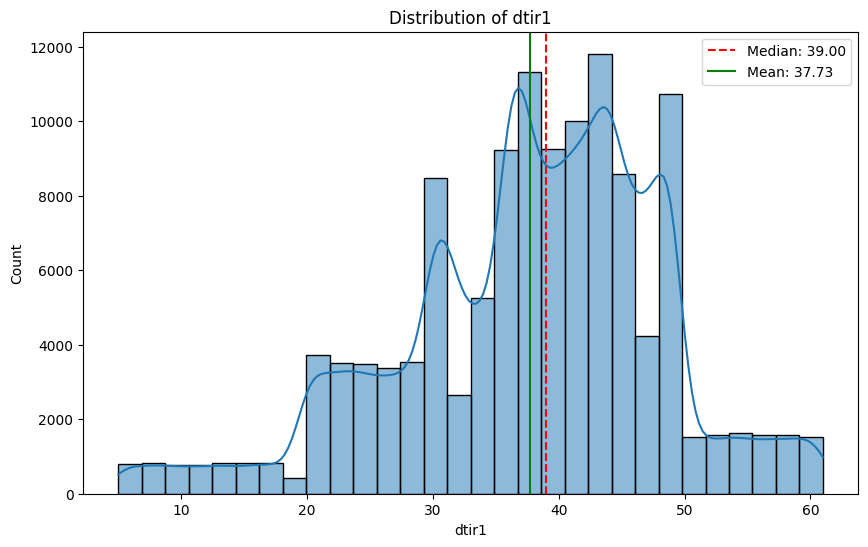

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_github['dtir1'].dropna(), kde=True, bins=30)
plt.title('Distribution of dtir1')
plt.axvline(df_github['dtir1'].median(), color='red', linestyle='--', label=f'Median: {df_github["dtir1"].median():.2f}')
plt.axvline(df_github['dtir1'].mean(), color='green', linestyle='-', label=f'Mean: {df_github["dtir1"].mean():.2f}')
plt.legend()
plt.show()

Given the distribution, the median is a safe choice for basic imputation. I'll also add a flag so the model knows the value was originally missing (which preserves that information).

In [80]:

# Create quartiles for dtir1
# We use 'duplicates=drop' just in case the distribution is heavily skewed at certain values
df_github['dtir1_quartiles'] = pd.qcut(df_github['dtir1'], q=4)

# Generate the contingency table
ct_quartiles = pd.crosstab(df_github['dtir1_quartiles'], df_github['Status'], normalize='index') * 100
ct_counts = pd.crosstab(df_github['dtir1_quartiles'], df_github['Status'])

print("Contingency Table (Percentages per Quartile):")
display(ct_quartiles)

print("\nContingency Table (Raw Counts):")
display(ct_counts)

Contingency Table (Percentages per Quartile):


Status,0,1
dtir1_quartiles,,
"(4.999, 31.0]",85.012430,14.987570
"(31.0, 39.0]",87.800437,12.199563
"(39.0, 45.0]",86.106446,13.893554
"(45.0, 61.0]",74.751344,25.248656



Contingency Table (Raw Counts):


Status,0,1
dtir1_quartiles,,
"(4.999, 31.0]",27357,4823
"(31.0, 39.0]",28932,4020
"(39.0, 45.0]",26662,4302
"(45.0, 61.0]",21269,7184


###Property value


In [81]:
# Create a binary flag: 1 if missing, 0 if present
df_github['property_value_is_missing'] = df_github['property_value'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['property_value_is_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['property_value_is_missing'])
print("Contingency Table: property_value_is_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: property_value_is_missing (Row) vs Status (Column)


Status,0,1,All
property_value_is_missing,,,
0,112029,21543,133572
1,2,15096,15098
All,112031,36639,148670


###LTV


In [82]:
# Create a binary flag: 1 if missing, 0 if present
df_github['LTV_is_missing'] = df_github['LTV'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['LTV_is_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['LTV_is_missing'])
print("Contingency Table: LTV_is_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: LTV_is_missing (Row) vs Status (Column)


Status,0,1,All
LTV_is_missing,,,
0,112029,21543,133572
1,2,15096,15098
All,112031,36639,148670


###Income

In [83]:
# Create a binary flag: 1 if missing, 0 if present
df_github['income_missing'] = df_github['income'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['income_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['income_missing'])
print("Contingency Table: income_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: income_missing (Row) vs Status (Column)


Status,0,1,All
income_missing,,,
0,104120,35400,139520
1,7911,1239,9150
All,112031,36639,148670


In [84]:
# Create quartiles for dtir1
# We use 'duplicates=drop' just in case the distribution is heavily skewed at certain values
df_github['income_quart'] = pd.qcut(df_github['income'], q=4)

# Generate the contingency table
ct_quartiles = pd.crosstab(df_github['income_quart'], df_github['Status'], normalize='index') * 100
ct_counts = pd.crosstab(df_github['income_quart'], df_github['Status'])

print("Contingency Table (Percentages per Quartile):")
display(ct_quartiles)

print("\nContingency Table (Raw Counts):")
display(ct_counts)

Contingency Table (Percentages per Quartile):


Status,0,1
income_quart,,
"(-0.001, 3720.0]",64.487808,35.512192
"(3720.0, 5760.0]",75.472125,24.527875
"(5760.0, 8520.0]",78.998601,21.001399
"(8520.0, 578580.0]",79.780220,20.219780



Contingency Table (Raw Counts):


Status,0,1
income_quart,,
"(-0.001, 3720.0]",22770,12539
"(3720.0, 5760.0]",26656,8663
"(5760.0, 8520.0]",27106,7206
"(8520.0, 578580.0]",27588,6992


###Loan Limit

In [85]:
# Create a binary flag: 1 if missing, 0 if present
df_github['LL_missing'] = df_github['loan_limit'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['LL_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['LL_missing'])
print("Contingency Table: LL_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: LL_missing (Row) vs Status (Column)


Status,0,1,All
LL_missing,,,
0,109568,35758,145326
1,2463,881,3344
All,112031,36639,148670


### Age

In [86]:
# Create a binary flag: 1 if missing, 0 if present
df_github['age_missing'] = df_github['age'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['age_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['age_missing'])
print("Contingency Table: age_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: age_missing (Row) vs Status (Column)


Status,0,1,All
age_missing,,,
0,112031,36439,148470
1,0,200,200
All,112031,36639,148670


### Submission of application

In [87]:
# Create a binary flag: 1 if missing, 0 if present
df_github['submission_of_application_missing'] = df_github['submission_of_application'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['submission_of_application_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['submission_of_application_missing'])
print("Contingency Table: submission_of_application_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: submission_of_application_missing (Row) vs Status (Column)


Status,0,1,All
submission_of_application_missing,,,
0,112031,36439,148470
1,0,200,200
All,112031,36639,148670


In [88]:
import pandas as pd

# Create flags for missing values
age_is_nan = df_github['age'].isnull()
submission_is_nan = df_github['submission_of_application'].isnull()

# Create a contingency table to see the overlap
overlap_table = pd.crosstab(age_is_nan, submission_is_nan,
                            rownames=['Age Missing'],
                            colnames=['Submission Missing'],
                            margins=True)

print("Overlap between missing Age and missing Submission of Application:")
display(overlap_table)

# Explicitly check if the indices match
same_records = (df_github[age_is_nan].index == df_github[submission_is_nan].index).all()
print(f"\nDo both columns have missing values in exactly the same records? {same_records}")

Overlap between missing Age and missing Submission of Application:


Submission Missing,False,True,All
Age Missing,,,
False,148470,0,148470
True,0,200,200
All,148470,200,148670



Do both columns have missing values in exactly the same records? True


200 records with missing age are the same 200 records with missing submission_of_application.


### Loan Purpose


In [89]:
# Create a binary flag: 1 if missing, 0 if present
df_github['loan_purpose_missing'] = df_github['loan_purpose'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['loan_purpose_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['loan_purpose_missing'])
print("Contingency Table: loan_purpose_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: loan_purpose_missing (Row) vs Status (Column)


Status,0,1,All
loan_purpose_missing,,,
0,111932,36604,148536
1,99,35,134
All,112031,36639,148670


### Neg Ammortization

In [90]:
# Create a binary flag: 1 if missing, 0 if present
df_github['Neg_ammortization_missing'] = df_github['Neg_ammortization'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['Neg_ammortization_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['Neg_ammortization_missing'])
print("Contingency Table: Neg_ammortization_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: Neg_ammortization_missing (Row) vs Status (Column)


Status,0,1,All
Neg_ammortization_missing,,,
0,111942,36607,148549
1,89,32,121
All,112031,36639,148670


### Term

In [91]:
# Create a binary flag: 1 if missing, 0 if present
df_github['term_missing'] = df_github['term'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['term_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['term_missing'])
print("Contingency Table: term_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: term_missing (Row) vs Status (Column)


Status,0,1,All
term_missing,,,
0,112005,36624,148629
1,26,15,41
All,112031,36639,148670


#Pre processing

##Null values


In [92]:
if 'Upfront_charges' in df_github.columns:
    df_github = df_github.drop(columns=['Upfront_charges'])
    print("Column 'Upfront_charges' dropped successfully.")
else:
    print("Column 'Upfront_charges' not found in the DataFrame. Skipping drop operation.")

print("Current columns in DataFrame after dropping:")
print(df_github.columns)

Column 'Upfront_charges' dropped successfully.
Current columns in DataFrame after dropping:
Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'term', 'Neg_ammortization', 'interest_only',
       'lump_sum_payment', 'property_value', 'construction_type',
       'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type',
       'Credit_Score', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status',
       'dtir1', 'dtir1_quartiles', 'income_quart'],
      dtype='object')


In [93]:
columns_to_drop = ['rate_of_interest', 'Interest_rate_spread']

for col in columns_to_drop:
    if col in df_github.columns:
        df_github = df_github.drop(columns=[col])
        print(f"Column '{col}' dropped successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

print("Current columns in DataFrame after dropping:")
print(df_github.columns)

Column 'rate_of_interest' dropped successfully.
Column 'Interest_rate_spread' dropped successfully.
Current columns in DataFrame after dropping:
Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1', 'dtir1_quartiles', 'income_quart'],
      dtype='object')


In [94]:
# Reverting to median imputation for dtir1
#median_val = df_github['dtir1'].median()
#df_github['dtir1'] = df_github['dtir1'].fillna(median_val)

#print(f"Imputation complete. Missing values in 'dtir1': {df_github['dtir1'].isnull().sum()}")
#print(f"Median value used: {median_val}")

In [95]:
#Property value and LTV
columns_to_drop = ['property_value', 'LTV']

for col in columns_to_drop:
    if col in df_github.columns:
        df_github = df_github.drop(columns=[col])
        print(f"Column '{col}' dropped successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

print("Current columns in DataFrame after dropping:")
print(df_github.columns)

Column 'property_value' dropped successfully.
Column 'LTV' dropped successfully.
Current columns in DataFrame after dropping:
Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'construction_type',
       'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type',
       'Credit_Score', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'Region', 'Security_Type', 'Status',
       'dtir1', 'dtir1_quartiles', 'income_quart'],
      dtype='object')


In [96]:
#Income
#median_val = df_github['income'].median()
#df_github['income'] = df_github['income'].fillna(median_val)

#print(f"Imputation complete. Missing values in 'income': {df_github['income'].isnull().sum()}")
#print(f"Median value used: {median_val}")

In [97]:
# Sostituisci i valori nulli nella colonna 'loan_limit' con 'Unknown'
df_github['loan_limit'] = df_github['loan_limit'].fillna('Unknown')

print("Valori nulli nella colonna 'loan_limit' sostituiti con 'Unknown'.")
print("Valori unici e loro frequenze nella colonna 'loan_limit' dopo l'imputazione:")
print(df_github['loan_limit'].value_counts(dropna=False))

Valori nulli nella colonna 'loan_limit' sostituiti con 'Unknown'.
Valori unici e loro frequenze nella colonna 'loan_limit' dopo l'imputazione:
loan_limit
cf         135348
ncf          9978
Unknown      3344
Name: count, dtype: int64


In [98]:
# Impute 'term' with its median
#median_term = df_github['term'].median()
#df_github['term'] = df_github['term'].fillna(median_term)
#print(f"Missing values in 'term' after imputation: {df_github['term'].isnull().sum()}")
#print(f"Median value used for 'term': {median_term}")
#
## Impute 'loan_purpose' with its mode (most frequent value)
## .mode()[0] is used to handle cases where there might be multiple modes
#mode_loan_purpose = df_github['loan_purpose'].mode()[0]
#df_github['loan_purpose'] = df_github['loan_purpose'].fillna(mode_loan_purpose)
#print(f"\nMissing values in 'loan_purpose' after imputation: {df_github['loan_purpose'].isnull().sum()}")
#print(f"Mode value used for 'loan_purpose': {mode_loan_purpose}")
#
## Impute 'Neg_ammortization' with its mode
#mode_neg_ammortization = df_github['Neg_ammortization'].mode()[0]
#df_github['Neg_ammortization'] = df_github['Neg_ammortization'].fillna(mode_neg_ammortization)
#print(f"\nMissing values in 'Neg_ammortization' after imputation: {df_github['Neg_ammortization'].isnull().sum()}")
#print(f"Mode value used for 'Neg_ammortization': {mode_neg_ammortization}")


In [99]:
initial_rows = df_github.shape[0]
print(f"Initial number of rows: {initial_rows}")

# Drop rows where 'age' is null
# As confirmed earlier, these are the same rows where 'submission_of_application' is null
if 'age' in df_github.columns:
    df_github.dropna(subset=['age'], inplace=True)
    print(f"Number of rows after dropping nulls in 'age': {df_github.shape[0]}")
    print(f"Rows dropped: {initial_rows - df_github.shape[0]}")
else:
    print("Column 'age' not found. Skipping operation.")

# Verify if 'submission_of_application' still has nulls (it shouldn't if 'age' and 'submission_of_application' nulls are coincident)
if 'submission_of_application' in df_github.columns:
    missing_submission = df_github['submission_of_application'].isnull().sum()
    print(f"Missing values in 'submission_of_application' after operation: {missing_submission}")
else:
    print("Column 'submission_of_application' not found.")

Initial number of rows: 148670
Number of rows after dropping nulls in 'age': 148470
Rows dropped: 200
Missing values in 'submission_of_application' after operation: 0


In [100]:
# Check for duplicate rows in the entire DataFrame
duplicate_rows = df_github.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    # Optionally, display the duplicate rows
    # display(df_github[df_github.duplicated(keep=False)]) # keep=False shows all occurrences of duplicates
else:
    print("No duplicate rows found in the DataFrame.")

No duplicate rows found in the DataFrame.


##Duplicates


In [101]:
# Check for duplicate rows in the entire DataFrame
duplicate_rows = df_github.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    # Optionally, display the duplicate rows
    # display(df_github[df_github.duplicated(keep=False)]) # keep=False shows all occurrences of duplicates
else:
    print("No duplicate rows found in the DataFrame.")

No duplicate rows found in the DataFrame.


##Redundancies


In [102]:
columns_to_remove = ['construction_type', 'Security_Type']

for col in columns_to_remove:
    if col in df_github.columns:
        df_github = df_github.drop(columns=[col])
        print(f"Column '{col}' removed successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

print("Current columns in DataFrame after removal:")
print(df_github.columns)

Column 'construction_type' removed successfully.
Column 'Security_Type' removed successfully.
Current columns in DataFrame after removal:
Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'occupancy_type', 'Secured_by',
       'total_units', 'income', 'credit_type', 'Credit_Score',
       'co-applicant_credit_type', 'age', 'submission_of_application',
       'Region', 'Status', 'dtir1', 'dtir1_quartiles', 'income_quart'],
      dtype='object')


###Noise


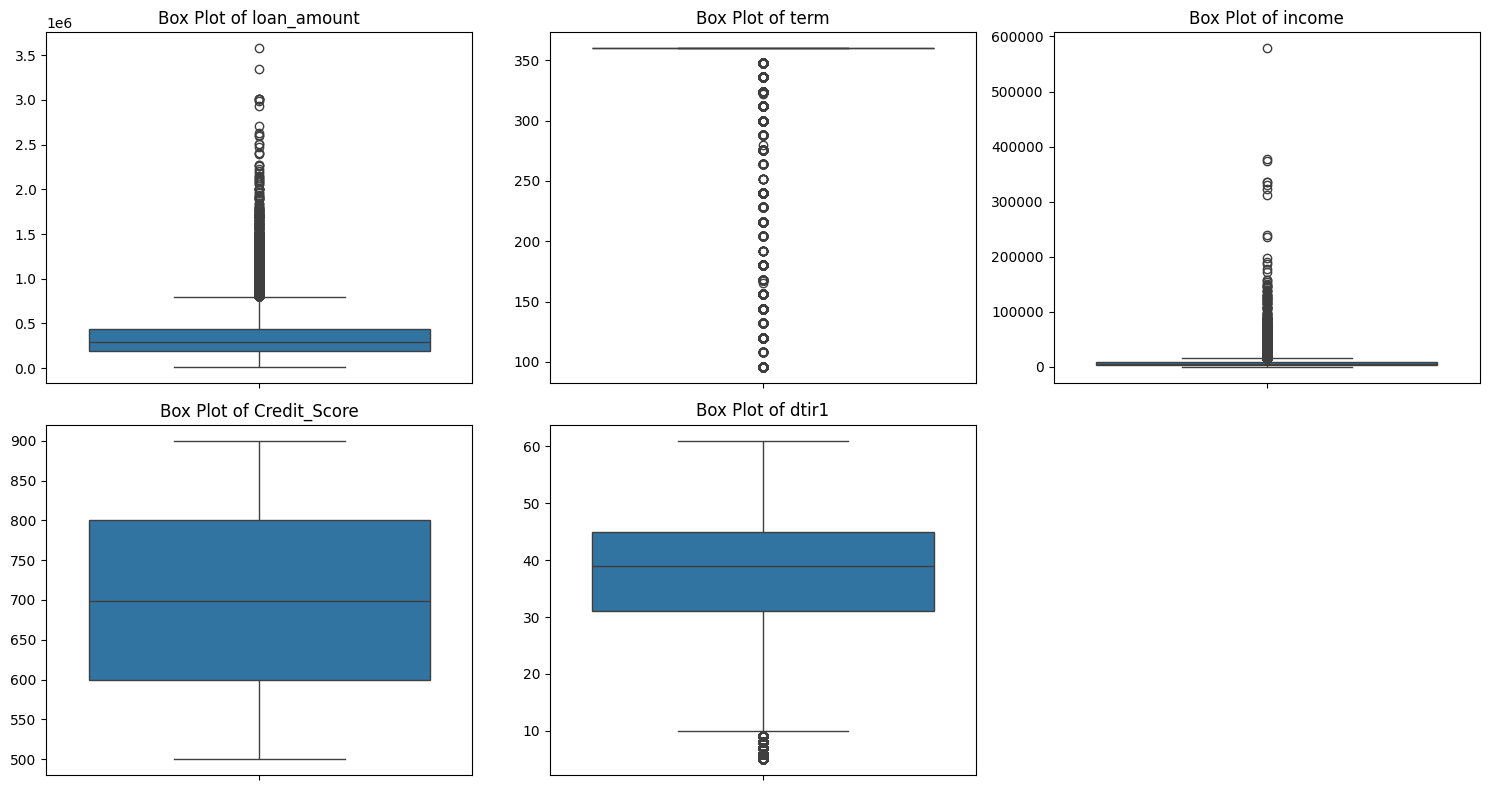

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for box plots
numerical_cols = df_github.select_dtypes(include=['int64', 'float64']).columns

# Filter out columns that might not be suitable for box plots (e.g., ID, or those with very few unique values that might be categorical)
numerical_cols = [col for col in numerical_cols if df_github[col].nunique() > 5 and col != 'ID' and col != 'Status' and col != 'year']

if not numerical_cols:
    print("No suitable numerical columns found for box plots after filtering.")
else:
    # Determine grid size
    n_cols = 3  # Number of columns in the plot grid
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 5, n_rows * 4))

    for i, col in enumerate(numerical_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(y=df_github[col])
        plt.title(f'Box Plot of {col}')
        plt.ylabel('') # Remove y-label to avoid clutter

    plt.tight_layout()
    plt.show()

###Useless columns

In [104]:
if 'ID' in df_github.columns:
    df_github = df_github.drop(columns=['ID'])
    print("Column 'ID' dropped successfully.")
else:
    print("Column 'ID' not found in the DataFrame. Skipping drop operation.")

if 'year' in df_github.columns:
    df_github = df_github.drop(columns=['year'])
    print("Column 'year' dropped successfully.")
else:
    print("Column 'year' not found in the DataFrame. Skipping drop operation.")

print("Current columns in DataFrame after ID and year removal:")
print(df_github.columns)

Column 'ID' dropped successfully.
Column 'year' dropped successfully.
Current columns in DataFrame after ID and year removal:
Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'loan_amount', 'term', 'Neg_ammortization', 'interest_only',
       'lump_sum_payment', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'Region', 'Status', 'dtir1',
       'dtir1_quartiles', 'income_quart'],
      dtype='object')


#Classification

In [105]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ======================================================================
# 1. Parto dal dataset originale del notebook
# ======================================================================

df = df_github.copy()

# target
y = df["Status"]
df = df.drop(columns=["Status"])

# ======================================================================
# 2. Train–test split stratificato
# ======================================================================

X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================================================
# 3. Definizione colonne numeriche e categoriche
# ======================================================================

num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeriche:", num_features)
print("Categoriche:", cat_features)

# ======================================================================
# 4. ColumnTransformer con imputazione (mediana/moda) + scaling/encoding
# ======================================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),      # mediana (dtir1, income, ecc.)
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # moda / categoria più frequente
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

# ======================================================================
# 5. Definizione delle 3 pipeline con SMOTE
# ======================================================================

smote = SMOTE(random_state=42)

pipe_lr = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight=None,
        n_jobs=-1
    ))
])

pipe_rf = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_estimators=200
    ))
])

base_tree = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=10,
    random_state=42
)

pipe_ada = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("clf", AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

# A questo punto pipe_lr, pipe_rf e pipe_ada sono pronte per:
# - RandomizedSearchCV / GridSearchCV
# - fit(X_train, y_train) e valutazione su X_test, y_test

Numeriche: ['loan_amount', 'term', 'income', 'Credit_Score', 'dtir1']
Categoriche: ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region']


#AFTER

In [106]:
print("Tabella di Contingenza per Secured_by e Status:")
display(pd.crosstab(df_github['Secured_by'], df_github['Status'], margins=True))

Tabella di Contingenza per Secured_by e Status:


Status,0,1,All
Secured_by,,,
home,112031,36406,148437
land,0,33,33
All,112031,36439,148470


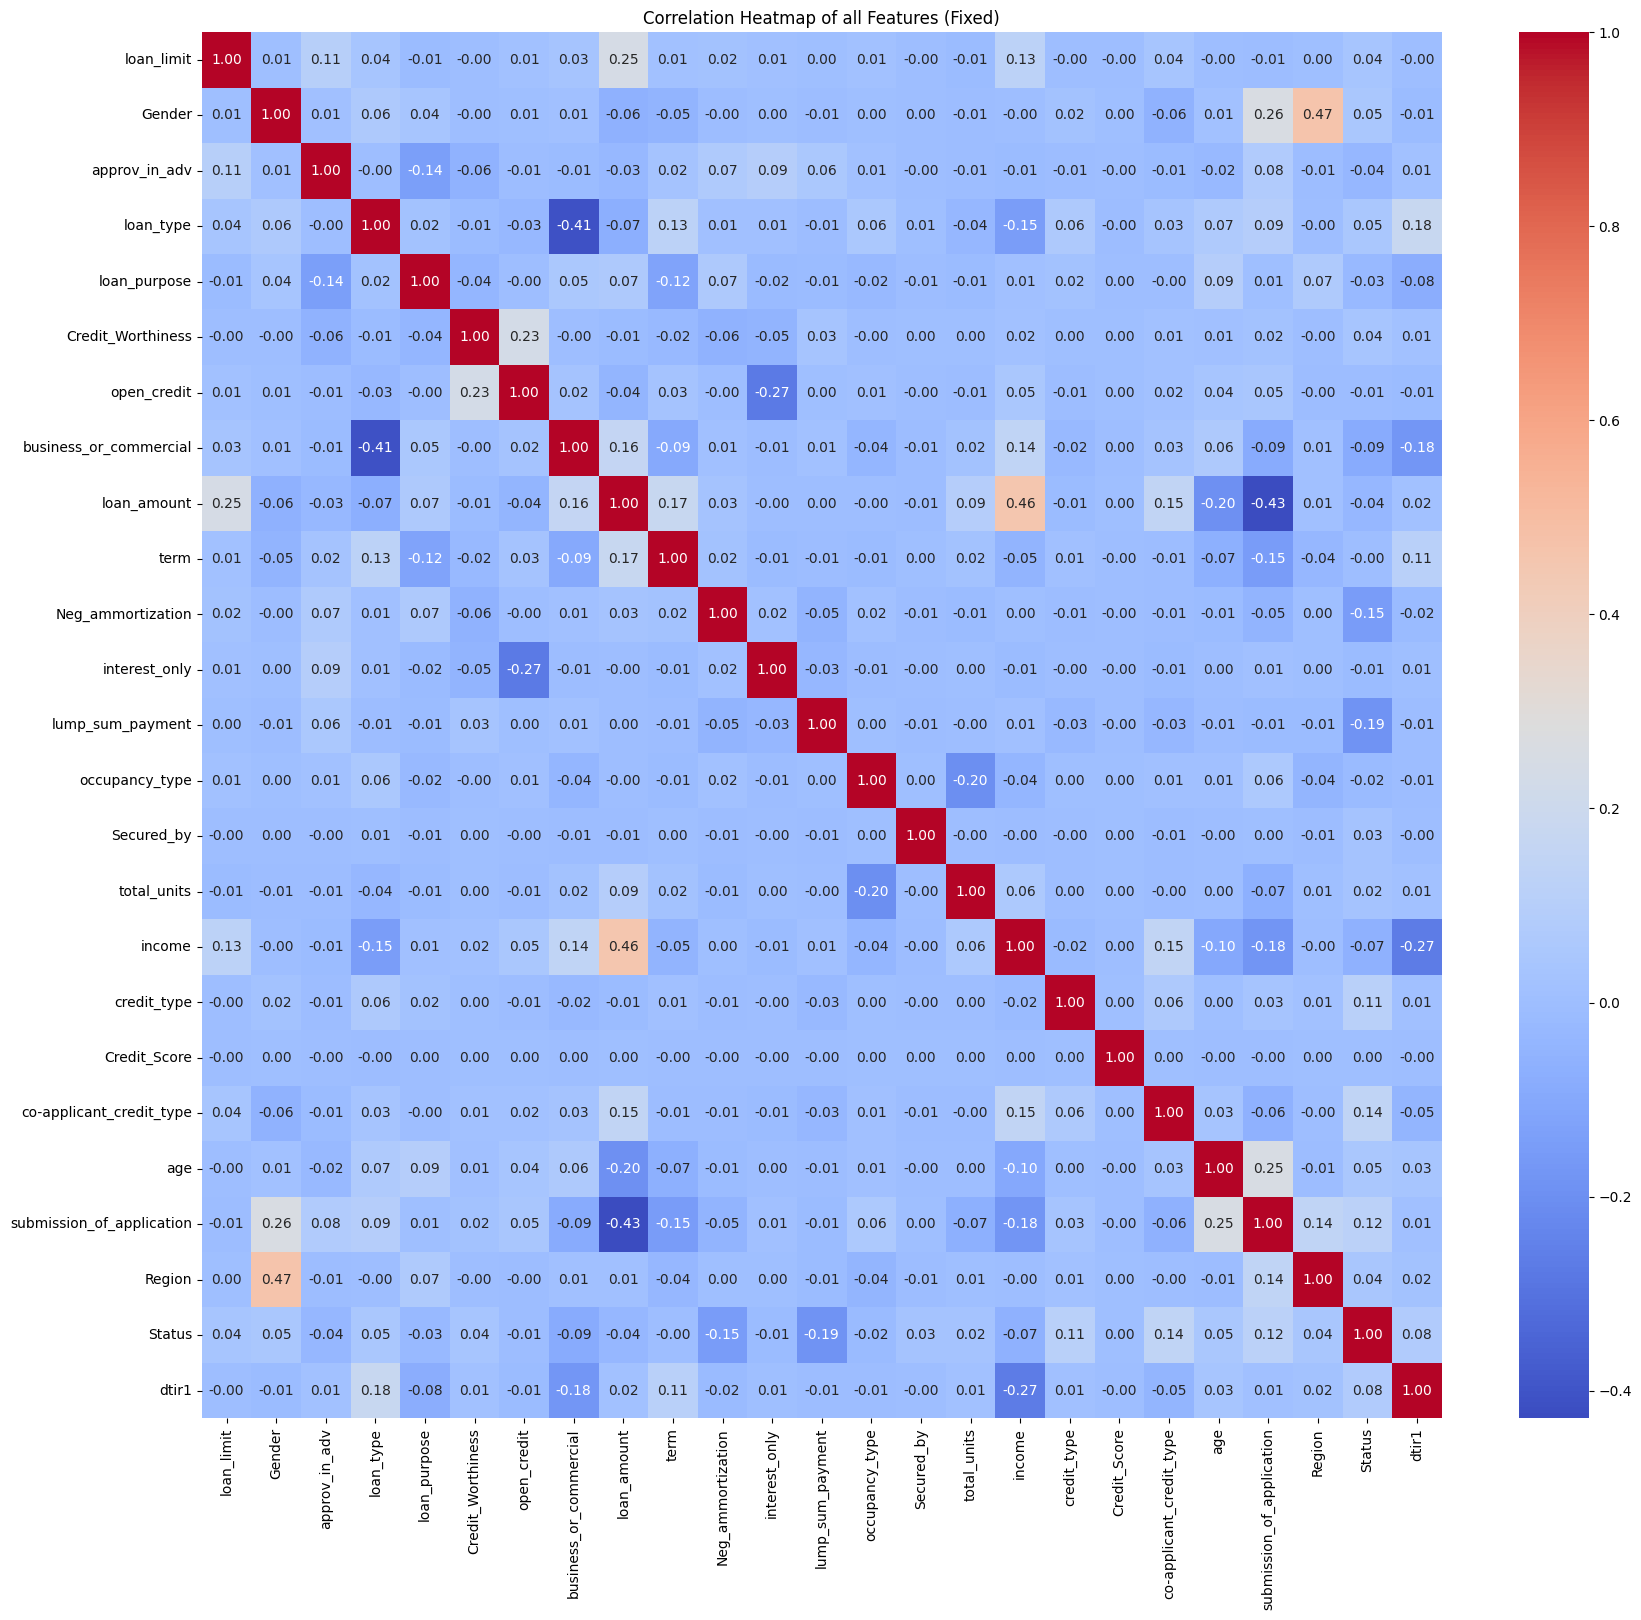

In [108]:

import pandas as pd

# Creazione di una copia del dataframe per l'analisi di correlazione
df_for_heatmap = df_github.copy()

# Rimuovi colonne identificative o costanti che non contribuiscono alla correlazione
# Aggiungiamo 'dtir1_quartiles' alla rimozione perché contiene oggetti Interval che causano il TypeError
df_for_heatmap = df_for_heatmap.drop(columns=['ID', 'year', 'dtir1_quartiles'], errors='ignore')

# Gestione delle colonne categoriche: codifica con Label Encoding
for column in df_for_heatmap.select_dtypes(include=['object']).columns:
    if df_for_heatmap[column].isnull().any():
        df_for_heatmap[column] = df_for_heatmap[column].fillna('Missing')
    le = LabelEncoder()
    df_for_heatmap[column] = le.fit_transform(df_for_heatmap[column])

# Escludiamo esplicitamente colonne non numeriche residue (come eventuali Interval o Categorical non convertiti)
df_for_heatmap = df_for_heatmap.select_dtypes(include=['number'])

# Calcola la matrice di correlazione
correlation_matrix = df_for_heatmap.corr()

# Traccia la heatmap con annotazioni numeriche
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of all Features (Fixed)')
plt.show()

Cose da fare su attributi:
- year si può togliere, tutti 2019
- approv_in_adv, dice già il risultato? va controllato? gestire NaN
- construction_type, secured_by, security_type 148637 vs 33 -> secondo me sono uguali (SI SONO RIDONDANTI, ne va lasciata solo una)
- Gestire NaN di attributi che ne hanno

-> fare correlation heatmap